# 🌧️ Nairobi Flood Risk — ML Model Training
**Output:** Flood risk score (0–100%) per location per hour

### Pipeline
1. Load real `nairobi_raw.csv`
2. Clean & validate
3. Engineer features
4. Train Gradient Boosting model (probability output)
5. Evaluate with charts
6. Save `flood_model.pkl`, `scaler.pkl`, `features.pkl`


## 0. Install Dependencies

In [13]:
%pip install pandas numpy scikit-learn joblib matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


## 1. Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay,
    brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
print(" Imports ready")

 Imports ready


## 2. Load Raw Data

In [15]:
df = pd.read_csv("nairobi_raw.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nDate range: {df['datetime'].min()} → {df['datetime'].max()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Shape: (61368, 13)
Columns: ['datetime', 'date', 'hour', 'month', 'day_of_year', 'latitude', 'longitude', 'precipitation_mm', 'rain_mm', 'humidity', 'wind_speed', 'temperature', 'cloud_cover']

Date range: 2018-01-01T00:00 → 2024-12-31T23:00

Missing values:
datetime            0
date                0
hour                0
month               0
day_of_year         0
latitude            0
longitude           0
precipitation_mm    0
rain_mm             0
humidity            0
wind_speed          0
temperature         0
cloud_cover         0
dtype: int64


,datetime,date,hour,month,day_of_year,latitude,longitude,precipitation_mm,rain_mm,humidity,wind_speed,temperature,cloud_cover
0,2018-01-01T00:00,2018-01-01,0,1,1,-1.286,36.817,0.0,0.0,66,6.4,17.1,14.0
1,2018-01-01T01:00,2018-01-01,1,1,1,-1.286,36.817,0.0,0.0,66,8.0,17.0,15.0
2,2018-01-01T02:00,2018-01-01,2,1,1,-1.286,36.817,0.0,0.0,67,8.2,16.4,19.0
3,2018-01-01T03:00,2018-01-01,3,1,1,-1.286,36.817,0.0,0.0,68,8.4,16.2,2.0
4,2018-01-01T04:00,2018-01-01,4,1,1,-1.286,36.817,0.0,0.0,69,7.3,15.8,33.0


## 3. Clean the Data

In [16]:
before = len(df)

df["datetime"] = pd.to_datetime(df["datetime"])
df["date"]     = pd.to_datetime(df["date"])

# Drop missing rainfall rows
df = df.dropna(subset=["precipitation_mm"])

# Remove impossible values
df = df[df["precipitation_mm"] >= 0]
df = df[df["precipitation_mm"] < 300]

# Clip to valid ranges
df["humidity"]    = df["humidity"].clip(0, 100)
df["wind_speed"]  = df["wind_speed"].clip(0, 100)
df["cloud_cover"] = df["cloud_cover"].clip(0, 100)

# Remove duplicates, sort chronologically
df = df.drop_duplicates(subset=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

print(f"Rows before cleaning : {before:,}")
print(f"Rows after cleaning  : {len(df):,}")
print(f"Removed              : {before - len(df):,} rows")
print(" Data clean")

Rows before cleaning : 61,368
Rows after cleaning  : 61,368
Removed              : 0 rows
 Data clean


## 4. Explore the Data

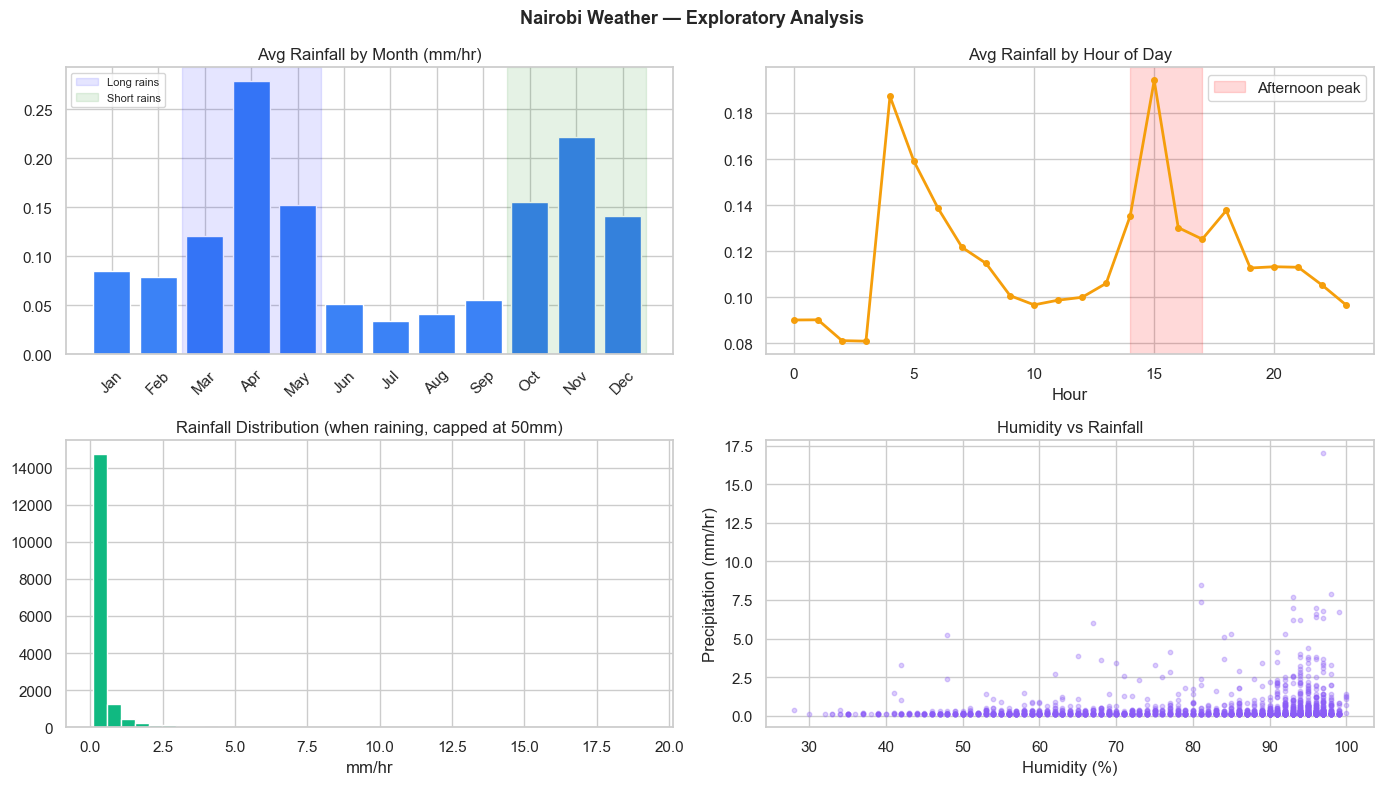

 Saved eda_charts.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Monthly avg rainfall
monthly = df.groupby("month")["precipitation_mm"].mean()
axes[0,0].bar(monthly.index, monthly.values, color="#3B82F6")
axes[0,0].set_title("Avg Rainfall by Month (mm/hr)")
axes[0,0].set_xticks(range(1,13))
axes[0,0].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], rotation=45)
axes[0,0].axvspan(2.5, 5.5, alpha=0.1, color="blue", label="Long rains")
axes[0,0].axvspan(9.5, 12.5, alpha=0.1, color="green", label="Short rains")
axes[0,0].legend(fontsize=8)

# Hourly pattern
hourly_avg = df.groupby("hour")["precipitation_mm"].mean()
axes[0,1].plot(hourly_avg.index, hourly_avg.values, color="#F59E0B", linewidth=2, marker="o", markersize=4)
axes[0,1].axvspan(14, 17, alpha=0.15, color="red", label="Afternoon peak")
axes[0,1].set_title("Avg Rainfall by Hour of Day")
axes[0,1].set_xlabel("Hour")
axes[0,1].legend()

# Rainfall distribution (non-zero)
rain_only = df[df["precipitation_mm"] > 0]["precipitation_mm"].clip(0, 50)
axes[1,0].hist(rain_only, bins=40, color="#10B981", edgecolor="white")
axes[1,0].set_title("Rainfall Distribution (when raining, capped at 50mm)")
axes[1,0].set_xlabel("mm/hr")

# Humidity vs rainfall scatter
sample = df[df["precipitation_mm"] > 0].sample(min(2000, len(df)))
axes[1,1].scatter(sample["humidity"], sample["precipitation_mm"].clip(0,50),
                  alpha=0.3, color="#8B5CF6", s=10)
axes[1,1].set_title("Humidity vs Rainfall")
axes[1,1].set_xlabel("Humidity (%)")
axes[1,1].set_ylabel("Precipitation (mm/hr)")

plt.suptitle("Nairobi Weather — Exploratory Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_charts.png", dpi=120, bbox_inches="tight")
plt.show()
print(" Saved eda_charts.png")

## 5. Feature Engineering
Cumulative rolling rain is the **strongest flood predictor** — a flood is caused by sustained rainfall, not a single heavy hour.


In [18]:
# Rolling cumulative rainfall
df["rain_3h_mm"]  = df["precipitation_mm"].rolling(3,  min_periods=1).sum()
df["rain_6h_mm"]  = df["precipitation_mm"].rolling(6,  min_periods=1).sum()
df["rain_24h_mm"] = df["precipitation_mm"].rolling(24, min_periods=1).sum()
df["rain_48h_mm"] = df["precipitation_mm"].rolling(48, min_periods=1).sum()

# Rain intensity buckets
df["is_heavy_rain"] = (df["precipitation_mm"] > 7.5).astype(int)   # WMO heavy rain threshold
df["is_light_rain"] = (df["precipitation_mm"].between(0.1, 2.5)).astype(int)

# Nairobi seasonal features
# Long rains: Mar–May | Short rains: Oct–Dec
df["is_rainy_season"] = df["month"].isin([3, 4, 5, 10, 11, 12]).astype(int)
df["is_peak_month"]   = df["month"].isin([4, 11]).astype(int)  # April & November peak

# Time of day — afternoon storms common in Nairobi
df["is_afternoon"] = df["hour"].between(14, 17).astype(int)
df["is_night"]     = (df["hour"] <= 5).astype(int)

# Humidity x rain interaction
df["humidity_rain"] = df["humidity"] * df["precipitation_mm"] / 100

print(" Features engineered:")
new_features = ["rain_3h_mm","rain_6h_mm","rain_24h_mm","rain_48h_mm",
                "is_heavy_rain","is_rainy_season","is_peak_month",
                "is_afternoon","humidity_rain"]
print(df[new_features].describe().round(2))

 Features engineered:
       rain_3h_mm  rain_6h_mm  rain_24h_mm  rain_48h_mm  is_heavy_rain  \
count    61368.00    61368.00     61368.00     61368.00       61368.00   
mean         0.35        0.71         2.83         5.66           0.00   
std          1.27        2.15         5.69         9.71           0.03   
min          0.00        0.00         0.00         0.00           0.00   
25%          0.00        0.00         0.10         0.40           0.00   
50%          0.00        0.10         0.80         1.90           0.00   
75%          0.20        0.60         3.00         6.70           0.00   
max         44.00       58.30        88.70       125.60           1.00   

       is_rainy_season  is_peak_month  is_afternoon  humidity_rain  
count          61368.0       61368.00      61368.00       61368.00  
mean               0.5           0.16          0.17           0.10  
std                0.5           0.37          0.37           0.47  
min                0.0           0.

## 6. Create Flood Label
Flood conditions for Nairobi based on known drainage capacity:
- Current hour > **10 mm/hr**, OR
- 3-hour total > **25 mm**, OR  
- 24-hour total > **50 mm**


Flood hours    : 146 (0.2%)
No-flood hours : 61,222 (99.8%)


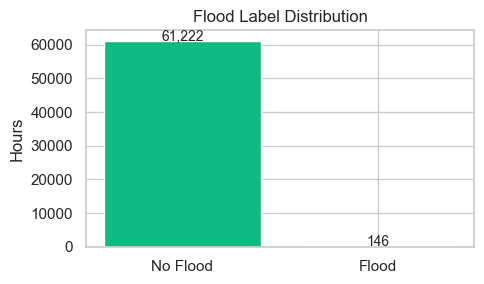

In [19]:
df["flood"] = (
    (df["precipitation_mm"] > 10) |
    (df["rain_3h_mm"]  > 25)      |
    (df["rain_24h_mm"] > 50)
).astype(int)

flood_pct = df["flood"].mean() * 100
print(f"Flood hours    : {df['flood'].sum():,} ({flood_pct:.1f}%)")
print(f"No-flood hours : {(df['flood']==0).sum():,} ({100-flood_pct:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 3))
counts = df["flood"].value_counts()
ax.bar(["No Flood", "Flood"], [counts[0], counts[1]], color=["#10B981","#EF4444"])
ax.set_title("Flood Label Distribution")
ax.set_ylabel("Hours")
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 7. Train the Model
Using **Gradient Boosting + Probability Calibration** so the output is a true 0–100% risk score, not just a raw probability.


In [20]:
FEATURES = [
    "precipitation_mm", "rain_3h_mm", "rain_6h_mm", "rain_24h_mm", "rain_48h_mm",
    "humidity", "wind_speed", "temperature", "cloud_cover",
    "month", "hour", "day_of_year",
    "is_rainy_season", "is_peak_month", "is_afternoon", "is_night",
    "is_heavy_rain", "humidity_rain",
    "latitude", "longitude"
]

X = df[FEATURES]
y = df["flood"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training set : {len(X_train):,} rows")
print(f"Test set     : {len(X_test):,} rows")
print(f"Flood rate   : {y_train.mean()*100:.1f}% (train) | {y_test.mean()*100:.1f}% (test)")
print("\nTraining model...")

base_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

# Calibrate so probabilities are accurate (important for risk scores!)
model = CalibratedClassifierCV(base_model, cv=3, method="sigmoid")
model.fit(X_train_s, y_train)

print("Model trained and calibrated!")

Training set : 49,094 rows
Test set     : 12,274 rows
Flood rate   : 0.2% (train) | 0.2% (test)

Training model...
Model trained and calibrated!


## 8. Evaluate Performance

In [21]:
y_pred  = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]  # flood probability 0–1

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["No Flood", "Flood"]))
print(f"ROC-AUC Score  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Brier Score    : {brier_score_loss(y_test, y_proba):.4f}  (lower = better calibration)")

# Risk score distribution
risk_scores = (y_proba * 100).round(1)
print(f"\nRisk score stats:")
print(pd.Series(risk_scores).describe().round(1))

=== Classification Report ===
              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00     12245
       Flood       0.97      0.97      0.97        29

    accuracy                           1.00     12274
   macro avg       0.98      0.98      0.98     12274
weighted avg       1.00      1.00      1.00     12274

ROC-AUC Score  : 1.0000
Brier Score    : 0.0001  (lower = better calibration)

Risk score stats:
count    12274.0
mean         0.2
std          4.7
min          0.0
25%          0.0
50%          0.0
75%          0.0
max         98.4
dtype: float64


## 9. Evaluation Charts

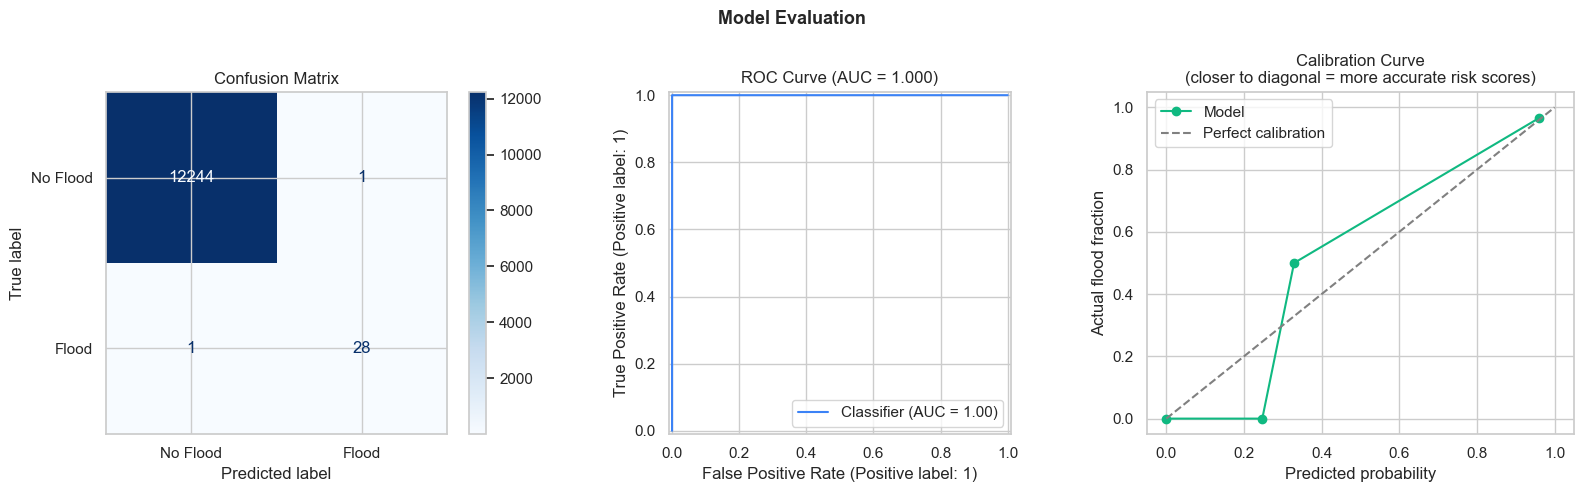

Saved model_evaluation.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No Flood","Flood"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Confusion Matrix")

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color="#3B82F6")
axes[1].set_title(f"ROC Curve (AUC = {roc_auc_score(y_test, y_proba):.3f})")

# Calibration curve — shows if probabilities are trustworthy
fraction_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10)
axes[2].plot(mean_pred, fraction_pos, marker="o", color="#10B981", label="Model")
axes[2].plot([0,1],[0,1], linestyle="--", color="gray", label="Perfect calibration")
axes[2].set_title("Calibration Curve\n(closer to diagonal = more accurate risk scores)")
axes[2].set_xlabel("Predicted probability")
axes[2].set_ylabel("Actual flood fraction")
axes[2].legend()

plt.suptitle("Model Evaluation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved model_evaluation.png")

## 10. Feature Importances

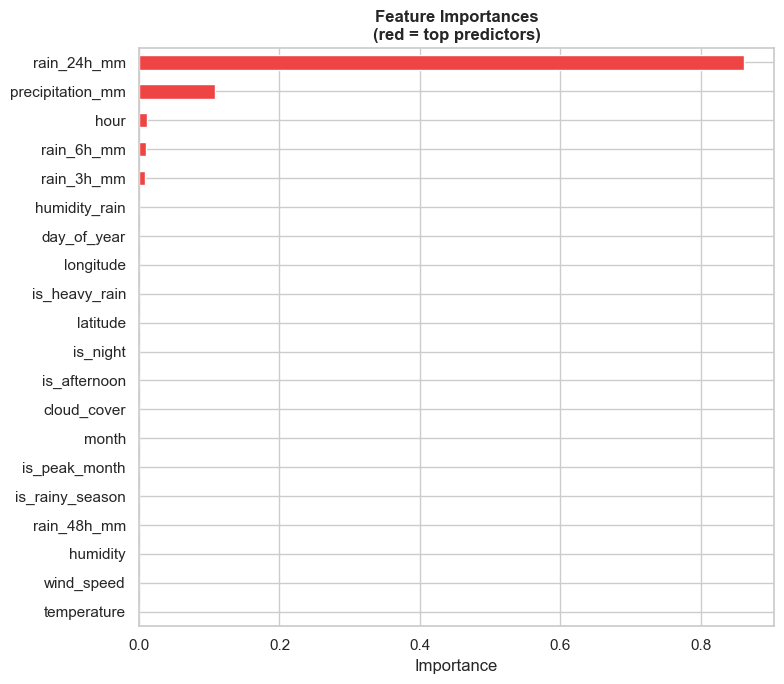

Saved feature_importance.png


In [23]:
# Extract importances from base estimator
base = model.calibrated_classifiers_[0].estimator
importances = pd.Series(base.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#EF4444" if i > importances.quantile(0.75) else "#3B82F6" for i in importances]
importances.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Feature Importances\n(red = top predictors)", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved feature_importance.png")

## 11. Test a Live Prediction
Simulate what your Flask server does — takes live weather values, returns a risk score.


In [24]:
def predict_flood_risk(weather: dict) -> dict:
    """
    Takes a weather dict and returns flood risk score 0-100.
    weather keys must match FEATURES list.
    """
    X = np.array([[weather[f] for f in FEATURES]])
    X_s = scaler.transform(X)
    prob = model.predict_proba(X_s)[0][1]
    score = round(prob * 100, 1)
    return {
        "flood_risk_score": score,
        "risk_level": "HIGH" if score > 65 else "MEDIUM" if score > 35 else "LOW",
        "description": (
            f"{ '⛔' if score > 65 else '⚠️' if score > 35 else '✅' } "
            f"{score}% flood probability"
        )
    }

# Test with heavy rainfall scenario (April — long rains)
heavy_rain = {
    "precipitation_mm": 15.0, "rain_3h_mm": 35.0, "rain_6h_mm": 55.0,
    "rain_24h_mm": 80.0, "rain_48h_mm": 95.0,
    "humidity": 88.0, "wind_speed": 12.0, "temperature": 18.0, "cloud_cover": 95.0,
    "month": 4, "hour": 15, "day_of_year": 105,
    "is_rainy_season": 1, "is_peak_month": 1, "is_afternoon": 1, "is_night": 0,
    "is_heavy_rain": 1, "humidity_rain": 13.2,
    "latitude": -1.286, "longitude": 36.817
}

# Test with dry scenario (July)
dry = {
    "precipitation_mm": 0.0, "rain_3h_mm": 0.0, "rain_6h_mm": 0.0,
    "rain_24h_mm": 0.5, "rain_48h_mm": 1.0,
    "humidity": 45.0, "wind_speed": 8.0, "temperature": 24.0, "cloud_cover": 20.0,
    "month": 7, "hour": 10, "day_of_year": 200,
    "is_rainy_season": 0, "is_peak_month": 0, "is_afternoon": 0, "is_night": 0,
    "is_heavy_rain": 0, "humidity_rain": 0.0,
    "latitude": -1.286, "longitude": 36.817
}

print("Heavy rainfall scenario (April afternoon):")
print(predict_flood_risk(heavy_rain))
print("\nDry scenario (July morning):")
print(predict_flood_risk(dry))

Heavy rainfall scenario (April afternoon):
{'flood_risk_score': np.float64(95.9), 'risk_level': 'HIGH', 'description': '⛔ 95.9% flood probability'}

Dry scenario (July morning):
{'flood_risk_score': np.float64(0.0), 'risk_level': 'LOW', 'description': '✅ 0.0% flood probability'}


## 12. Save Model Files
Drop these 3 files into your `ml/` folder alongside `predict_server.py`.


In [25]:
joblib.dump(model,    "flood_model.pkl")
joblib.dump(scaler,   "scaler.pkl")
joblib.dump(FEATURES, "features.pkl")

print(" Saved:")
print("   flood_model.pkl  → calibrated model (outputs true 0–100% risk scores)")
print("   scaler.pkl       → feature scaler")
print("   features.pkl     → feature list (20 features)")
print()
print("Next: copy these into ml/ and run:")
print("   python predict_server.py")

 Saved:
   flood_model.pkl  → calibrated model (outputs true 0–100% risk scores)
   scaler.pkl       → feature scaler
   features.pkl     → feature list (20 features)

Next: copy these into ml/ and run:
   python predict_server.py
